In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm # (Distribución Paramétrica) Se usa cuando asumes que tus datos siguen una campana de Gauss perfecta.
from scipy.stats import gaussian_kde # (Distribución No Paramétrica): Se usa cuando quieres que el modelo se adapte a la forma real de tus datos no exactamente normal.
import scipy.stats



In [3]:
########################## CARGA DESDE ARCHIVO LOCAL ##########################
# Cargar el archivo local
data_nodep = pd.read_csv("dataset_penguins.csv")
# Ver las primeras filas
display(data_nodep.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
# ELIMINAR los registros con valores nulos PERO antes reemplazar los nulos de sex por un valor como "no_definido"
# Creamos una copia profunda de los datos
data = data_nodep.copy()
# Llenamos los nulos de la columna 'sex' con una nueva categoría
data['sex'] = data['sex'].fillna('not-defined')
#Aunque los algoritmos modernos de Machine Learning (como XGBoost) saben manejar nulos por sí solos, muchas funciones estadísticas o de gráficas ignorarán filas con null o darán error si no las manejas antes.
# 1. Eliminar si no hay medidas (los datos realmente inservibles)
# por tanto afectar variables con valores numericos como ['body_mass_g', 'bill_length_mm']
variables_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
data = data.dropna(subset=variables_num)
# dropna() elimina filas con nulos en las columnas especificadas en subset.
# Ahora puedes comparar ambos
print(f"Filas originales: {len(data_nodep)}")
print(f"Filas limpias: {len(data)}")

Filas originales: 344
Filas limpias: 342


Conocer (e investigar) la función de;  
Funcion de probabilidad de masas (PMF)  
Funcion de probabilidad acumulada  (CDF)  
Funcion de probabilidad de densidad (PDF)  
Sirve para modelar la incertidumbre de forma matemática, calcular probabilidades de eventos y tomar decisiones basadas en datos (riesgo, predicción, control de calidad, inferencia estadística)  
  
Ej con la base de datos clásica de los pingüinos (Palmer Penguins)  
PMF → especie, isla, sexo  
PDF → masa corporal, longitud del pico  
CDF → percentiles de peso, mediana, rangos, conteo de pingüinos por año

| Función | Variable | Da probabilidad directa | Gráfica típica  |
| ------- | -------- | ----------------------- | --------------- |
| PMF     | Discreta | Sí                      | Barras          |
| PDF     | Continua | No (solo áreas)         | Curva           |
| CDF     | Ambas    | Sí (acumulada)          | Curva creciente |
** La forma de la variable (discreta o continua) determina qué función usamos.
  
  
🔹 PMF – Probability Mass Function  
Para variables discretas (categorías, conteos).  
Por tanto, no es solo para números discretos, también aplica a variables categóricas.  
Por ejemplo, la variable 'species' es una variable categórica, y tambien una variable aleatoria discreta.  
-Da la probabilidad exacta de cada valor.  
Es básicamente frecuencia relativa / porcentaje.  
Se ve como barras.  
Ej: P(especie = Adelie)  
  
  
  
🔹 PDF – Probability Density Function  
Para variables continuas (peso, altura).  
No da probabilidades directas en un punto.  
La probabilidad es el área bajo la curva entre dos valores.  
Se ve como curva suave (normal, KDE).  
Ej: densidad del peso corporal  
  
🔹 CDF – Cumulative Distribution Function  
Para discretas y continuas.  
Da la probabilidad acumulada hasta un valor.  
Siempre va de 0 a 1 y nunca decrece.  
Permite leer mediana, percentiles.  
Ej: P(peso ≤ 4000 g)  

##########################################################################################################
## PDF – Probability Density Function (Función de Densidad de Probabilidad)
  
La PDF describe cómo se distribuye la probabilidad a lo largo de una variable continua.  
NO responde directamente probabilidades.  
  
La PDF responde preguntas del tipo:  
- ¿Dónde se concentran más los valores?  
- ¿En qué rangos hay mayor densidad de observaciones?  
- ¿Cuál es la forma de la distribución? (simétrica, sesgada, multimodal)  
  
### Propiedades clave de la PDF:  
- La PDF nunca es negativa  
- El área total bajo la curva es igual a 1 (o 100%).  
- El valor de la PDF en un punto NO es una probabilidad  
- La PDF se interpreta **principalmente como una gráfica**, no como una tabla.
  
### Por qué la PDF no da probabilidades puntuales:  
En variables continuas: P(X = x) = 0  
Ejemplo: No tiene sentido preguntar: - "¿Cuál es la probabilidad de pesar exactamente 4000 g?"  
Porque hay infinitos valores posibles alrededor de 4000.  
  
### Cómo se obtienen probabilidades con la PDF:  
Las probabilidades se calculan como áreas bajo la curva:  
P(a ≤ X ≤ b) = área bajo la PDF entre a y b  
Esto conecta directamente con la CDF:  
CDF(x) = área bajo la PDF desde (-∞ hasta x)  
  
### Relación entre PDF y CDF:  
- La CDF es la integral de la PDF  
    CDF(x) = ∫ PDF(t) dt  
    Para obtener la CDF a partir de la PDF, se integra el área bajo la curva desde el valor mínimo hasta un valor específico.  
- La PDF es la derivada de la CDF (cuando existe)  
    PDF(x) = d/dx [CDF(x)]  
    La PDF es la tasa de acumulación de probabilidad por unidad de variable.  
    No por unidad de probabilidad, sino por unidad de peso, altura, tiempo, etc.  
  
### La PDF sirve para:  
Ver forma de la distribución  
Detectar:  
    asimetría  
    colas largas  
    concentración  
    multimodalidad (o casi multimodalidad)  
Comparar grupos (ej. Gentoo vs Adelie)  
  
  
### Diferencia entre Histograma y PDF:  
Histograma → muestra frecuencias empíricas (datos reales)  
PDF (KDE) → es una suavización de esos datos  
Por tanto, la PDF se usa para entender la distribución y la dispersión sin el "ruido" de las cajas (bins).  
En una PDF, el valor del eje Y NO es la probabilidad. Se llama Densidad.  


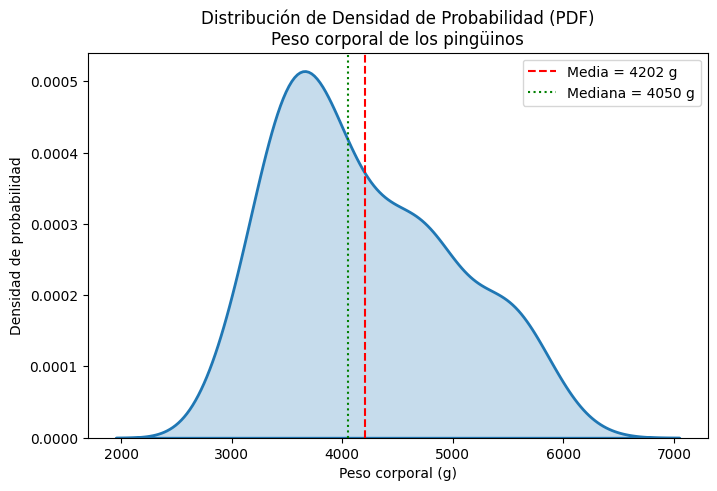

In [6]:
import seaborn as sns
import numpy as np

peso = data['body_mass_g'].dropna()

media = peso.mean()
mediana = peso.median()

plt.figure(figsize=(8, 5))

sns.kdeplot(
    peso,
    fill=True,
    linewidth=2
)

# Líneas de referencia
plt.axvline(media, color='red', linestyle='--', label=f"Media = {media:.0f} g")
plt.axvline(mediana, color='green', linestyle=':', label=f"Mediana = {mediana:.0f} g")

plt.title("Distribución de Densidad de Probabilidad (PDF)\nPeso corporal de los pingüinos")
plt.xlabel("Peso corporal (g)")
plt.ylabel("Densidad de probabilidad")

plt.legend()
plt.show()


## 📈 Interpretación de la PDF del peso corporal de los pingüinos

### 1️ Forma general de la distribución

La gráfica muestra una **distribución continua, unimodal pero asimétrica**, con un pico principal alrededor de los **3 500–4 000 g** y una **cola extendida hacia valores altos de peso**.

No es una campana de Gauss perfecta:

* el lado derecho cae más lentamente
* aparecen "lomos" suaves hacia **4 800–6 000 g** que se pueden apreciar en histogramas correctamente calibrados.

Esto indica que **no todos los pingüinos pertenecen a una única población homogénea**.

---

### 2️ Relación entre media y mediana (clave)

* **Media ≈ 4 202 g** (línea roja)
* **Mediana ≈ 4 050 g** (línea verde)
* **Media > Mediana**

👉 Esto confirma **asimetría positiva (sesgo a la derecha)**.

Importante: **este sesgo no es causado por valores extremos aislados**, sino por la **presencia sistemática de pingüinos más pesados**, que extienden la cola derecha de la distribución.

---

### 3️ Origen del sesgo (interpretación contextual)

Dado que el conjunto de datos incluye **múltiples especies**, la forma de la PDF refleja una **mezcla de poblaciones**:

* La mayor densidad central corresponde a especies más ligeras (ej. Adelie)
* La cola derecha corresponde a especies consistentemente más pesadas (ej. Gentoo)

📌 Por tanto, la asimetría observada es **estructural**, no un artefacto estadístico.
(PENDIENTE HAVER PRUEBA DE HIPOTESIS)

---

### 4️ Qué NO debe interpretarse aquí
* ❌ No se puede hablar de una “normal mal ajustada”
* ❌ No es apropiado interpretar la media como “el peso típico” de *todas* las especies
* ❌ No es una distribución ideal para inferencias paramétricas sin segmentar


### 6️ Conclusión analítica (redacción tipo informe)

> *La distribución de densidad del peso corporal presenta asimetría positiva, evidenciada por una media mayor que la mediana y una cola derecha prolongada. Esta asimetría no responde a la presencia de valores atípicos, sino a la combinación de múltiples especies con masas corporales significativamente distintas. La PDF sugiere que el conjunto de datos no corresponde a una única población homogénea, por lo que análisis segmentados por especie resultan más apropiados para caracterizar el peso típico.*

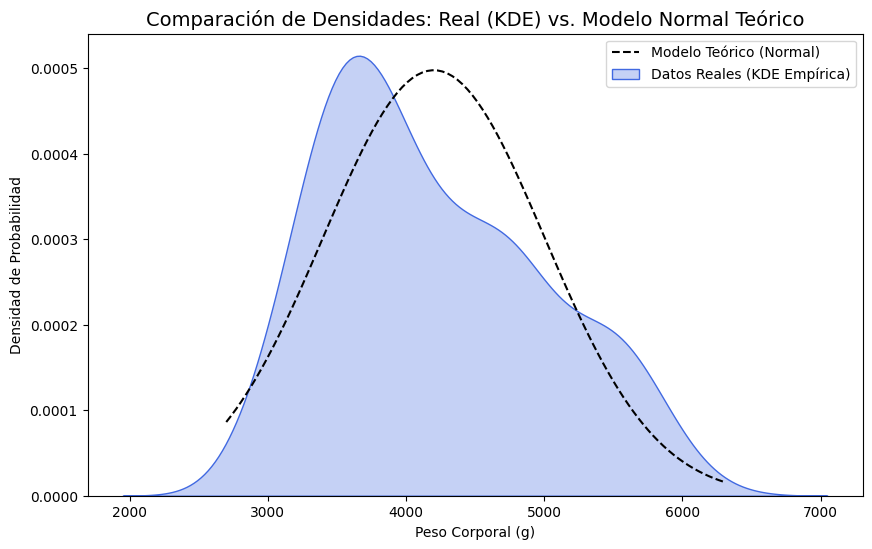

In [8]:
############################## COMPARACIÓN DE DENSIDADES: REALIDAD VS TEORÍA (PDF) ##########################

# 1. Obtener estadísticos descriptivos
stats = data['body_mass_g'].describe()

# 2. Generar el modelo teórico (PDF de la Distribución Normal)
# Creamos el rango de X (pesos)
xs = np.linspace(stats['min'], stats['max'], 100)

# IMPORTANTE: Aquí usamos .pdf(xs) en lugar de .cdf(xs)
ys = scipy.stats.norm(stats['mean'], stats['std']).pdf(xs)

# 3. Graficar la Teoría (Campana de Gauss ideal)
plt.figure(figsize=(10, 6))
plt.plot(xs, ys, color='black', linestyle='dashed', label='Modelo Teórico (Normal)')

# 4. Graficar la Realidad (Empírica) usando KDE
# Usamos sns.kdeplot porque es la versión "suave" de la realidad (PDF empírica)
sns.kdeplot(data=data, x='body_mass_g', fill=True, color='royalblue', 
            label='Datos Reales (KDE Empírica)', alpha=0.3)

# Configuración final
plt.title("Comparación de Densidades: Real (KDE) vs. Modelo Normal Teórico", fontsize=14)
plt.xlabel("Peso Corporal (g)")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()

Esta gráfica compara la **distribución real** de los datos de peso corporal de pingüinos (KDE empírica, área azul) contra un **modelo teórico normal** (línea punteada negra) ajustado con la media y desviación estándar de esos mismos datos.

## Conclusión

La distribución empírica del peso corporal de los pingüinos presenta bimodalidad aparente y asimetría positiva, lo que indica que los datos no se ajustan bien a un modelo normal único. Esto sugiere la presencia de subgrupos con medias distintas (probablemente especies diferentes). Para análisis predictivos o inferenciales, se recomienda modelar por separado cada especie o usar un modelo de mezcla de normales en lugar de una normal simple.

### 1. Los datos reales NO siguen una distribución normal perfecta
- La curva azul (KDE de datos reales) tiene sub picos, mientras que la normal teórica tiene un solo pico centrado.
- Esto sugiere que hay al menos dos subgrupos con pesos corporales distintos mezclados en los datos (probablemente especies diferentes de pingüinos con masas promedio distintas).

### 2. Diferencias en la forma
- La distribución real es más ancha y achatada que la normal teórica en algunas zonas, especialmente hacia la derecha (pesos mayores a ~5000 g).
- El modelo normal "asume" simetría perfecta, pero los datos reales muestran asimetría (la cola derecha es más larga).

### 2. Implicación práctica
- No deberías usar una distribución normal para modelar estos datos si necesitas precisión, porque la estructura bimodal indica heterogeneidad (mezcla de poblaciones).
- Si separas por especie (Adelie, Chinstrap, Gentoo), probablemente cada grupo sí se aproxime mejor a una normal individual.
